# L-Maze: Comparison

## Setup

In [1]:
# uncomment if needed
# %pip install "gym-classics2 @ git+https://github.com/mhahsler/gym-classics2.git"

In [2]:
import numpy as np
np.set_printoptions(precision=2)

SEED = 42
rng = np.random.default_rng(SEED)

In [3]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

## The L-Maze Grid World 

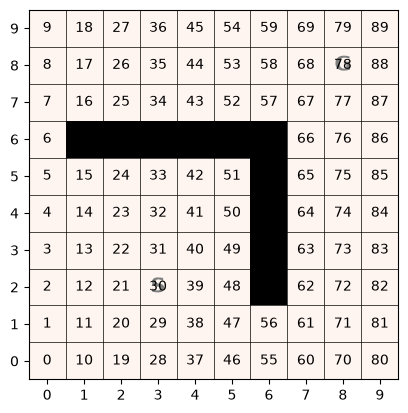

In [4]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped
env.reset(seed=SEED)

env.image()

## Comparison

To compare the algorithm, we use: 
* Episodes: 5000 episodes.
* Exploration: a schedule that reduces $\epsilon$ over the first 2500 episodes.
* Learning rate: $\alpha$ between 0.01 and 0.001.
* Discount rate: a $\gamma=0.99$ to encourage the algorithm to find the shorter path.

In [5]:
from gym_classics2.algorithms.schedules import LinearDecaySchedule

eps_schedule = LinearDecaySchedule(.5, 0.0, 2500)

In [6]:
from gym_classics2.performance import plot_returns, plot_ep_lens
avg_returns = {}
avg_ep_length = {}

### Monte Carlo Methods


#### Monte Carlo Control With Exploring Starts 

I use here only Monte-Carlo Control with exploring starts. Monte-Carlo Control with $\epsilon$-soft policy can also be used. 

MC Control (Incremental): 100%|██████████| 5000/5000 [00:02<00:00, 2271.46it/s]


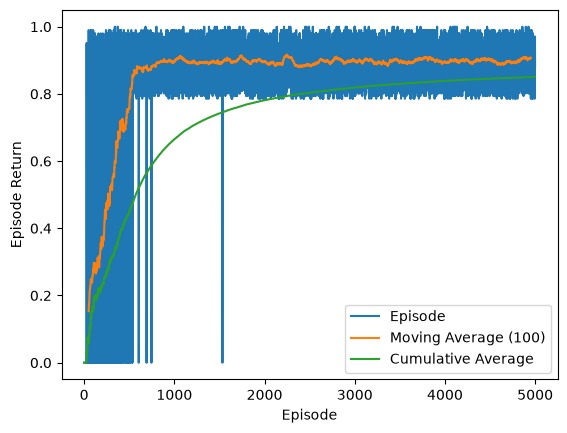

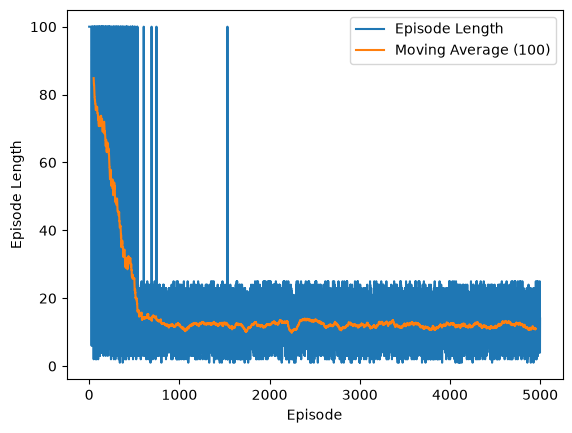

In [7]:
from gym_classics2.algorithms.monte_carlo_methods import MC_control_ES

policy, Q, history = MC_control_ES(env, n=5000, discount=.99, history=True, rng=rng)

plot_returns(history["returns"])
plot_ep_lens([len(x) for x in history["episodes"]])

# We cannot use the results from exploring starts because episodes do not start from the start state
avg_returns["MC Control ES"] = np.nan
avg_ep_length["MC Control ES"] = np.nan

Note: The remaining variability comes from the random restarts.

### Tabular Temporal Differencing Methods

#### Sarsa(0)


Sarsa:   0%|          | 0/5000 [00:00<?, ?it/s]

Sarsa: 100%|██████████| 5000/5000 [00:03<00:00, 1255.51it/s]


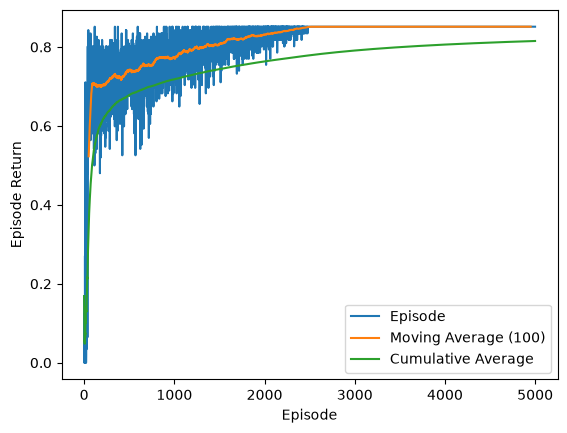

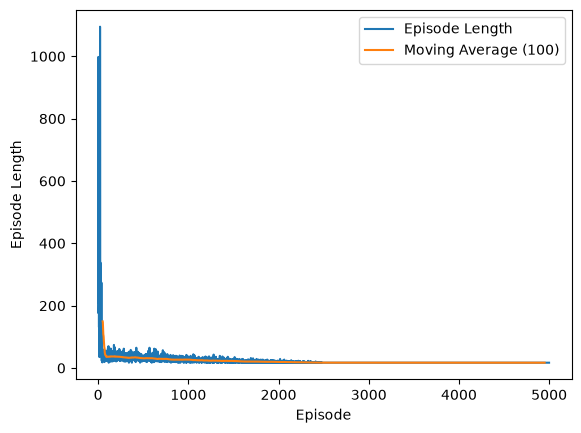

In [8]:
from gym_classics2.algorithms.temporal_difference_learning import Sarsa_0

Q, history = Sarsa_0(env, n=5000, discount=.99, alpha=0.01, epsilon=eps_schedule, history=True, rng=rng)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["Sarsa(0)"] = np.mean(history["returns"])
avg_ep_length["Sarsa(0)"] = np.mean(history["ep_lens"])

#### Q-Learning

**Note:** Q-Learning is off-policy and does not need a epsilon schedule. 
We just use it for comparison with the other methods.


Q-Learning: 100%|██████████| 5000/5000 [00:03<00:00, 1586.62it/s]


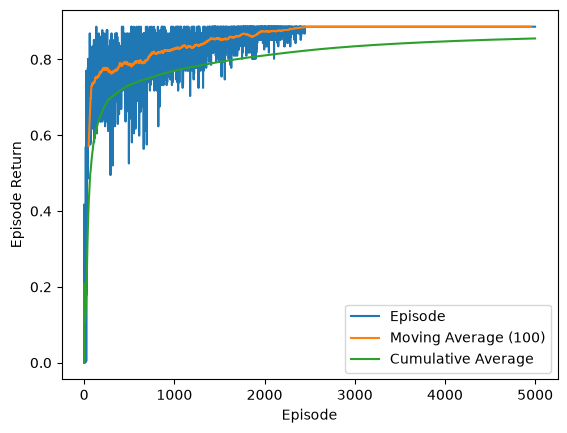

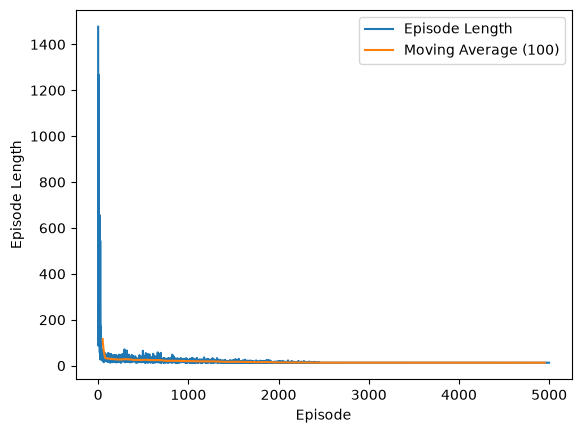

In [9]:
from gym_classics2.algorithms.temporal_difference_learning import Q_learning
from gym_classics2.algorithms.schedules import StepSchedule

Q, history = Q_learning(env, n=5000, discount=.99, alpha=0.01, 
                        epsilon=eps_schedule, history=True, rng=rng)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["Q-learning"] = np.mean(history["returns"])
avg_ep_length["Q-learning"] = np.mean(history["ep_lens"])

### Approximation Methods

We use Fourier basis features.

In [10]:
gym_env = gym.make('LMaze-v0', tabular=False)
env = gym_env.unwrapped
env.reset(seed=SEED)

((3, 2), {})

In [11]:
from gym_classics2.algorithms.linear_approximation import transformation_fourier_basis

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

# define the Fourier basis features used by the approximation algorithms
def state_features(s, env):
    return trans_fb(s)


#### Semi-Gradient Sarsa(0)


Semi-Gradient SARSA(0): 100%|██████████| 5000/5000 [00:10<00:00, 454.59it/s]


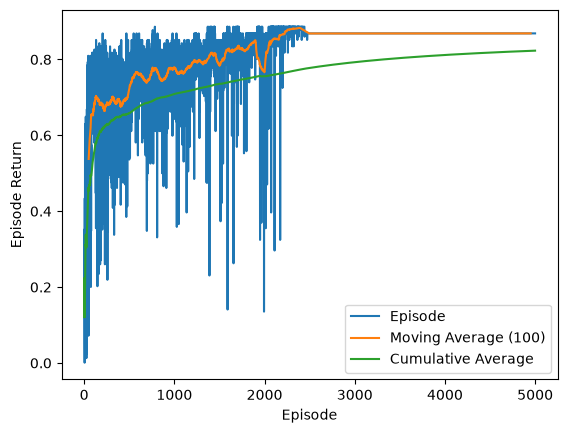

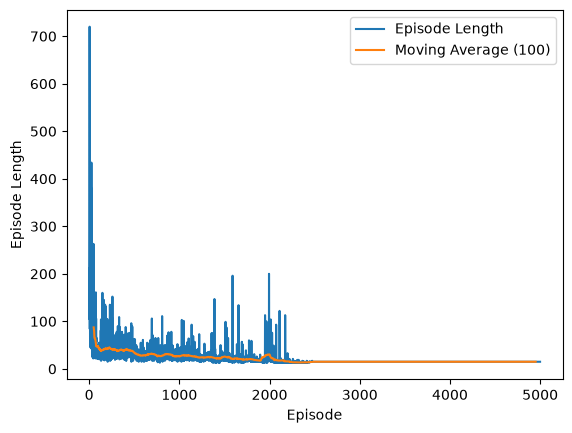

In [12]:
from gym_classics2.algorithms.linear_approximation import semi_gradient_Sarsa_0

w, history = semi_gradient_Sarsa_0(env, state_features, n=5000, gamma=.99, alpha=0.01, epsilon=eps_schedule, history=True, rng=rng)
plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["Semi-gradient Sarsa(0)"] = np.mean(history["returns"])
avg_ep_length["Semi-gradient Sarsa(0)"] = np.mean(history["ep_lens"])


#### Semi-Gradient Sarsa($\lambda$)


Semi-Gradient SARSA(lambda): 100%|██████████| 5000/5000 [00:19<00:00, 254.06it/s]


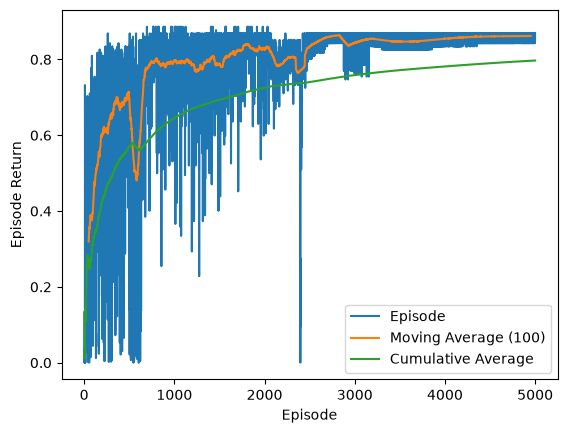

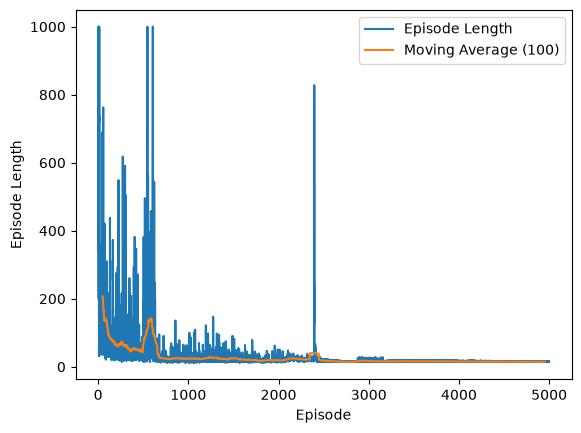

In [13]:
from gym_classics2.algorithms.eligibility_traces import semi_gradient_Sarsa_lambda
w, history = semi_gradient_Sarsa_lambda(env, state_features, n=5000, gamma=.99, lam=0.1, alpha=0.001, 
                                        epsilon=eps_schedule, history=True, verbose=False, rng=rng)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["Semi-gradient Sarsa(lambda)"] = np.mean(history["returns"])
avg_ep_length["Semi-gradient Sarsa(lambda)"] = np.mean(history["ep_lens"])


### Policy-Gradient Methods

#### REINFORCE

Episodes: 100%|██████████| 5000/5000 [00:47<00:00, 105.36it/s]


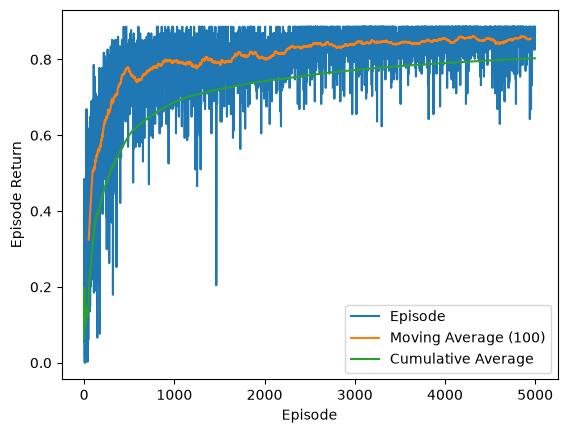

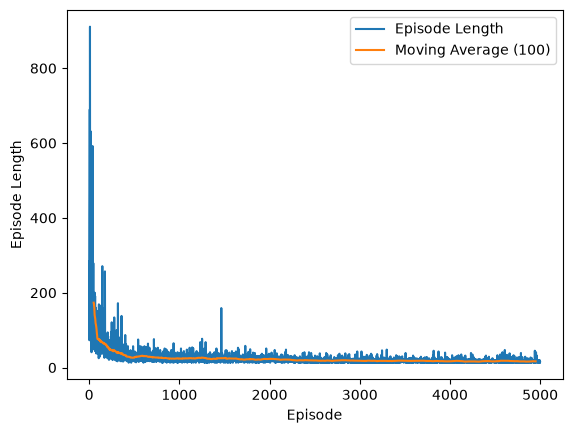

In [15]:
from gym_classics2.algorithms.policy_gradient_methods import REINFORCE

theta, history = REINFORCE(env, state_features=state_features, n=5000, gamma=.99, alpha=.01, history=True, verbose=False, rng=rng)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["REINFORCE alpha=.01"] = np.mean(history["returns"])
avg_ep_length["REINFORCE alpha=.01"] = np.mean(history["ep_lens"])


#### Actor-Critic Method

Episodes: 100%|██████████| 5000/5000 [01:16<00:00, 65.75it/s] 


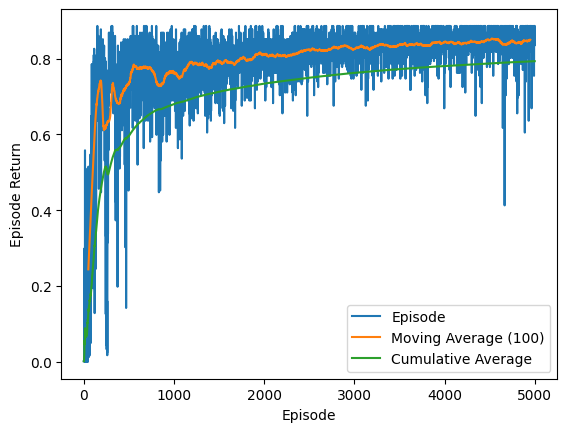

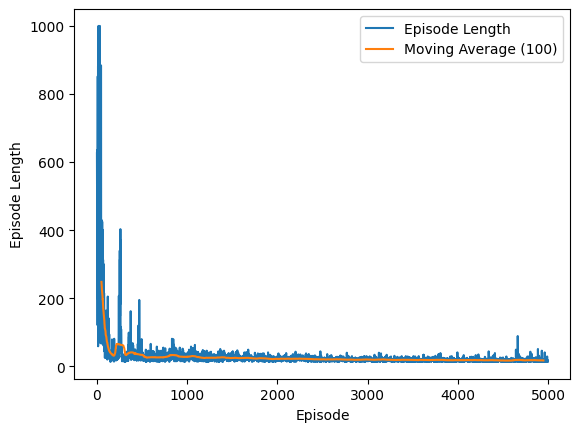

In [ ]:
from gym_classics2.algorithms.policy_gradient_methods import AC

theta, w, history = AC(env, state_features=state_features, n=5000, gamma=.99, 
                    alpha_policy=0.01,
                    alpha_value=0.01,
                    history=True, verbose=False, rng=rng)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

avg_returns["Actor-Critic"] = np.mean(history["returns"])
avg_ep_length["Actor-Critic"] = np.mean(history["ep_lens"])

### Compare the Average Return

**Important note:** For a generalizable comparison, you should rerun each experiment many times with different seeds and report the mean and
standard deviation. Since this takes too long in my notebook, I compare here only one run.

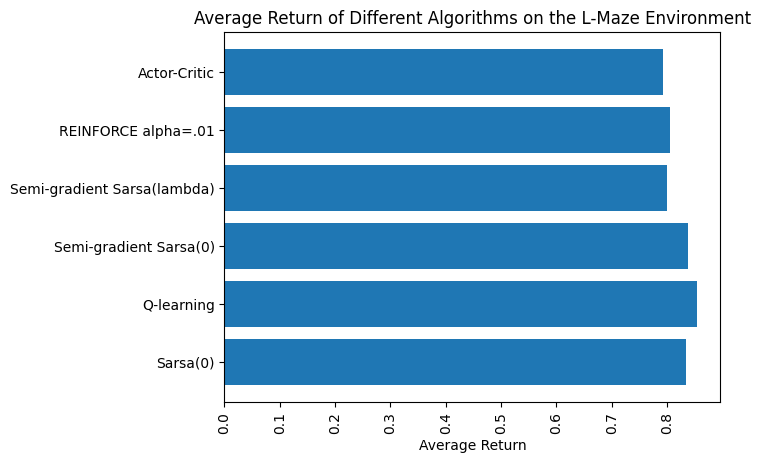

In [ ]:
from matplotlib import pyplot as plt

plt.barh(avg_returns.keys(), avg_returns.values())
plt.xlabel("Average Return")
plt.title("Average Return of Different Algorithms on the L-Maze Environment")
plt.xticks(rotation=90)
plt.show()

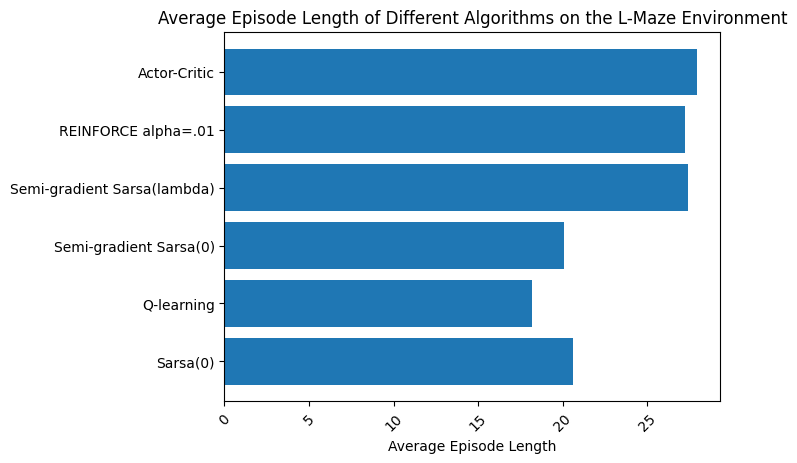

In [ ]:
plt.barh(avg_ep_length.keys(), avg_ep_length.values())
plt.xlabel("Average Episode Length")
plt.title("Average Episode Length of Different Algorithms on the L-Maze Environment")
plt.xticks(rotation=45)
plt.show()

Tabular Q-Learning is really hard to beat on small and simple problems.


&copy; 2025 [Michael Hahsler](https://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)